Import Libraries and load the dataset

In [1]:
import pandas as pd

data = pd.read_csv("classData.csv")

print(data.shape)
print(data.head())
print(data.columns)
print(data.info())

(7861, 10)
   G  C  B  A          Ia          Ib          Ic        Va        Vb  \
0  1  0  0  1 -151.291812   -9.677452   85.800162  0.400750 -0.132935   
1  1  0  0  1 -336.186183  -76.283262   18.328897  0.312732 -0.123633   
2  1  0  0  1 -502.891583 -174.648023  -80.924663  0.265728 -0.114301   
3  1  0  0  1 -593.941905 -217.703359 -124.891924  0.235511 -0.104940   
4  1  0  0  1 -643.663617 -224.159427 -132.282815  0.209537 -0.095554   

         Vc  
0 -0.267815  
1 -0.189099  
2 -0.151428  
3 -0.130570  
4 -0.113983  
Index(['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 no

Data Understanding

In [2]:
print(data[['G', 'C', 'B', 'A']].drop_duplicates())

      G  C  B  A
0     1  0  0  1
1129  1  0  1  1
2263  0  1  1  0
3267  0  1  1  1
4363  1  1  1  1
5496  0  0  0  0


In [4]:
print(data[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']].describe())

                Ia           Ib           Ic           Va           Vb  \
count  7861.000000  7861.000000  7861.000000  7861.000000  7861.000000   
mean     13.721194   -44.845268    34.392394    -0.007667     0.001152   
std     464.741671   439.269195   371.107412     0.289150     0.313437   
min    -883.542316  -900.526951  -883.357762    -0.620748    -0.608016   
25%    -119.802518  -271.845947   -61.034219    -0.130287    -0.159507   
50%       2.042805     5.513317    -4.326711    -0.005290     0.001620   
75%     227.246377    91.194282    49.115141     0.111627     0.153507   
max     885.738571   889.868884   901.274261     0.595342     0.627875   

                Vc  
count  7861.000000  
mean      0.006515  
std       0.307897  
min      -0.612709  
25%      -0.215977  
50%       0.009281  
75%       0.239973  
max       0.600179  


In [5]:
print(data[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']].head())

           Ia          Ib          Ic        Va        Vb        Vc
0 -151.291812   -9.677452   85.800162  0.400750 -0.132935 -0.267815
1 -336.186183  -76.283262   18.328897  0.312732 -0.123633 -0.189099
2 -502.891583 -174.648023  -80.924663  0.265728 -0.114301 -0.151428
3 -593.941905 -217.703359 -124.891924  0.235511 -0.104940 -0.130570
4 -643.663617 -224.159427 -132.282815  0.209537 -0.095554 -0.113983


In [6]:
print(data[['G', 'C', 'B', 'A']].value_counts())

G  C  B  A
0  0  0  0    2365
1  0  1  1    1134
   1  1  1    1133
   0  0  1    1129
0  1  1  1    1096
         0    1004
Name: count, dtype: int64


In [7]:
def get_fault_type(row):
    G, C, B, A = row['G'], row['C'], row['B'], row['A']

    if A == 0 and B == 0 and C == 0 and G == 0:
        return 'Normal'
    elif A == 1 and B == 0 and C == 0 and G == 1:
        return 'LG'
    elif A == 0 and B == 1 and C == 1 and G == 0:
        return 'LL'
    elif A == 1 and B == 1 and C == 0 and G == 1:
        return 'LLG'
    elif A == 1 and B == 1 and C == 1 and G == 0:
        return 'LLL'
    elif A == 1 and B == 1 and C == 1 and G == 1:
        return 'LLLG'
    else:
        return 'Unknown'

data['Fault_Type'] = data.apply(get_fault_type, axis=1)

print(data[['G', 'C', 'B', 'A', 'Fault_Type']].head(20))

    G  C  B  A Fault_Type
0   1  0  0  1         LG
1   1  0  0  1         LG
2   1  0  0  1         LG
3   1  0  0  1         LG
4   1  0  0  1         LG
5   1  0  0  1         LG
6   1  0  0  1         LG
7   1  0  0  1         LG
8   1  0  0  1         LG
9   1  0  0  1         LG
10  1  0  0  1         LG
11  1  0  0  1         LG
12  1  0  0  1         LG
13  1  0  0  1         LG
14  1  0  0  1         LG
15  1  0  0  1         LG
16  1  0  0  1         LG
17  1  0  0  1         LG
18  1  0  0  1         LG
19  1  0  0  1         LG


In [8]:
print(data['Fault_Type'].value_counts())

Fault_Type
Normal    2365
LLG       1134
LLLG      1133
LG        1129
LLL       1096
LL        1004
Name: count, dtype: int64


Exploratory data analysis

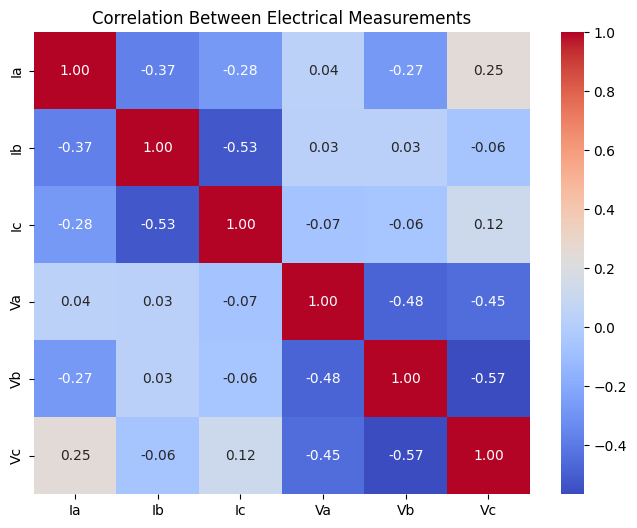

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

correlation = data[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Between Electrical Measurements')
plt.show()

In [11]:
X = data[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']]

In [12]:
y = data['Fault_Type']

Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6288, 6)
(1573, 6)
(6288,)
(1573,)


In [15]:
print("Original:")
print(y.value_counts(normalize=True))

print("\nTraining:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Original:
Fault_Type
Normal    0.300852
LLG       0.144256
LLLG      0.144129
LG        0.143620
LLL       0.139422
LL        0.127719
Name: proportion, dtype: float64

Training:
Fault_Type
Normal    0.300891
LLG       0.144243
LLLG      0.144084
LG        0.143607
LLL       0.139472
LL        0.127704
Name: proportion, dtype: float64

Testing:
Fault_Type
Normal    0.300699
LLLG      0.144310
LLG       0.144310
LG        0.143675
LLL       0.139224
LL        0.127781
Name: proportion, dtype: float64


Baseline Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8823903369357915


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          LG       0.99      1.00      0.99       226
          LL       1.00      1.00      1.00       201
         LLG       1.00      0.99      1.00       227
         LLL       0.59      0.56      0.58       219
        LLLG       0.59      0.62      0.61       227
      Normal       1.00      1.00      1.00       473

    accuracy                           0.88      1573
   macro avg       0.86      0.86      0.86      1573
weighted avg       0.88      0.88      0.88      1573



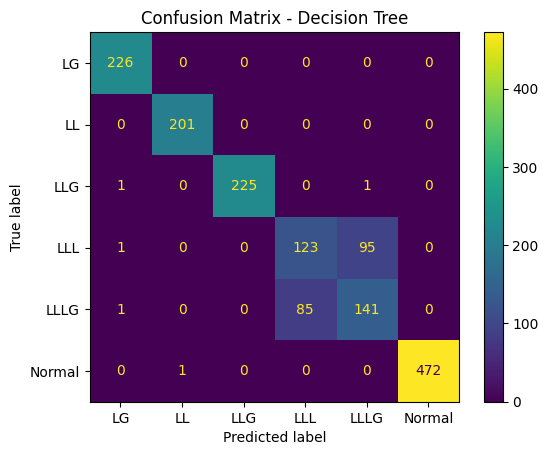

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Feature Engineering

In [20]:
data['I_mag'] = (data['Ia']**2 + data['Ib']**2 + data['Ic']**2)**0.5

data['V_mag'] = (data['Va']**2 + data['Vb']**2 + data['Vc']**2)**0.5

data['I_imbalance'] = (
    data[['Ia', 'Ib', 'Ic']].abs().max(axis=1)
    - data[['Ia', 'Ib', 'Ic']].abs().min(axis=1)
)

data['V_imbalance'] = (
    data[['Va', 'Vb', 'Vc']].abs().max(axis=1)
    - data[['Va', 'Vb', 'Vc']].abs().min(axis=1)
)

In [21]:
print(data[['Ia', 'Ib', 'Ic', 'I_mag',
            'Va', 'Vb', 'Vc', 'V_mag',
            'I_imbalance', 'V_imbalance']].head())

           Ia          Ib          Ic       I_mag        Va        Vb  \
0 -151.291812   -9.677452   85.800162  174.196824  0.400750 -0.132935   
1 -336.186183  -76.283262   18.328897  345.219110  0.312732 -0.123633   
2 -502.891583 -174.648023  -80.924663  538.470684  0.265728 -0.114301   
3 -593.941905 -217.703359 -124.891924  644.794333  0.235511 -0.104940   
4 -643.663617 -224.159427 -132.282815  694.297519  0.209537 -0.095554   

         Vc     V_mag  I_imbalance  V_imbalance  
0 -0.267815  0.499997   141.614361     0.267815  
1 -0.189099  0.385804   317.857286     0.189099  
2 -0.151428  0.326507   421.966920     0.151428  
3 -0.130570  0.289009   469.049981     0.130570  
4 -0.113983  0.256960   511.380802     0.113983  


In [22]:
features = [
    'Ia', 'Ib', 'Ic',
    'Va', 'Vb', 'Vc',
    'I_mag', 'V_mag',
    'I_imbalance', 'V_imbalance'
]

X_new = data[features]

In [23]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
model_new = DecisionTreeClassifier(random_state=42)

model_new.fit(X_train_new, y_train_new)

y_pred_new = model_new.predict(X_test_new)

accuracy_new = accuracy_score(y_test_new, y_pred_new)

print("New Accuracy:", accuracy_new)

New Accuracy: 0.954227590591227


In [25]:
print(classification_report(y_test_new, y_pred_new))

              precision    recall  f1-score   support

          LG       0.99      0.99      0.99       226
          LL       1.00      1.00      1.00       201
         LLG       1.00      1.00      1.00       227
         LLL       0.85      0.85      0.85       219
        LLLG       0.85      0.85      0.85       227
      Normal       1.00      1.00      1.00       473

    accuracy                           0.95      1573
   macro avg       0.95      0.95      0.95      1573
weighted avg       0.95      0.95      0.95      1573



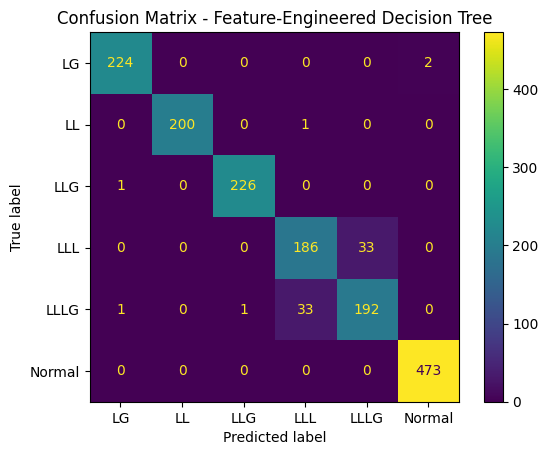

In [26]:
cm_new = confusion_matrix(y_test_new, y_pred_new)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_new,
    display_labels=model_new.classes_
)

disp.plot()
plt.title("Confusion Matrix - Feature-Engineered Decision Tree")
plt.show()

Random Forest Accuracy: 0.9548633184996821

Classification Report:
              precision    recall  f1-score   support

          LG       0.99      1.00      1.00       226
          LL       1.00      1.00      1.00       201
         LLG       1.00      0.99      0.99       227
         LLL       0.84      0.84      0.84       219
        LLLG       0.85      0.85      0.85       227
      Normal       1.00      1.00      1.00       473

    accuracy                           0.95      1573
   macro avg       0.95      0.95      0.95      1573
weighted avg       0.95      0.95      0.95      1573



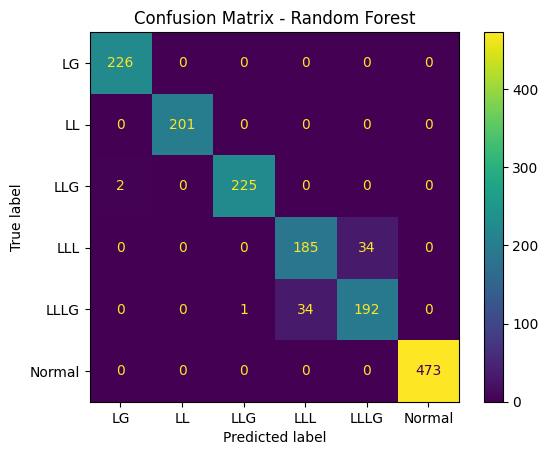

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Define the features
features = [
    'Ia', 'Ib', 'Ic',
    'Va', 'Vb', 'Vc',
    'I_mag', 'V_mag',
    'I_imbalance', 'V_imbalance'
]

X_new = data[features]
y = data['Fault_Type']


# 2. Train-test split
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 3. Create the Random Forest
rf_model = RandomForestClassifier(
    random_state=42
)


# 4. Train the model
rf_model.fit(X_train_new, y_train_new)


# 5. Make predictions
y_pred_rf = rf_model.predict(X_test_new)


# 6. Calculate accuracy
accuracy_rf = accuracy_score(y_test_new, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)


# 7. Classification report
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_rf))


# 8. Confusion matrix
cm_rf = confusion_matrix(y_test_new, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [28]:
importance = pd.Series(
    model_new.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

I_mag          0.356699
V_mag          0.201053
Ic             0.174558
Va             0.115064
Ib             0.036553
Ia             0.033366
I_imbalance    0.030616
Vc             0.021588
V_imbalance    0.017666
Vb             0.012836
dtype: float64


Model Comparison

In [30]:
print("Decision Tree")
print(classification_report(y_test_new, y_pred_new))

Decision Tree
              precision    recall  f1-score   support

          LG       0.99      0.99      0.99       226
          LL       1.00      1.00      1.00       201
         LLG       1.00      1.00      1.00       227
         LLL       0.85      0.85      0.85       219
        LLLG       0.85      0.85      0.85       227
      Normal       1.00      1.00      1.00       473

    accuracy                           0.95      1573
   macro avg       0.95      0.95      0.95      1573
weighted avg       0.95      0.95      0.95      1573



In [31]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          LG       0.99      1.00      1.00       226
          LL       1.00      1.00      1.00       201
         LLG       1.00      0.99      0.99       227
         LLL       0.84      0.84      0.84       219
        LLLG       0.85      0.85      0.85       227
      Normal       1.00      1.00      1.00       473

    accuracy                           0.95      1573
   macro avg       0.95      0.95      0.95      1573
weighted avg       0.95      0.95      0.95      1573



Cross Validation

In [32]:
from sklearn.model_selection import cross_val_score
dt_cv = DecisionTreeClassifier(random_state=42)
cv_scores = cross_val_score(
    dt_cv,
    X_train_new,
    y_train_new,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [0.94356121 0.95389507 0.95707472 0.95465394 0.94351631]
Mean CV accuracy: 0.9505402496417519
Standard deviation: 0.005812389402941861


In [33]:
train_pred = model_new.predict(X_train_new)

train_accuracy = accuracy_score(y_train_new, train_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", accuracy_new)

Training Accuracy: 1.0
Testing Accuracy: 0.954227590591227


In [34]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
train_sizes, train_scores, validation_scores = learning_curve(
    model_new,
    X_new,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

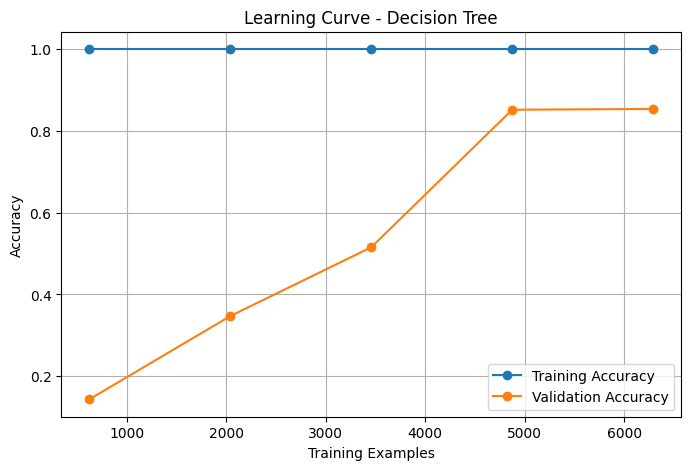

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, validation_mean, marker='o', label='Validation Accuracy')

plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Decision Tree')
plt.legend()
plt.grid()

plt.show()

In [36]:
print(data[['G', 'C', 'B', 'A']].head(10))

print("\nFirst index of each fault combination:")
print(
    data.groupby(['G', 'C', 'B', 'A'])
        .apply(lambda x: x.index.min())
)

   G  C  B  A
0  1  0  0  1
1  1  0  0  1
2  1  0  0  1
3  1  0  0  1
4  1  0  0  1
5  1  0  0  1
6  1  0  0  1
7  1  0  0  1
8  1  0  0  1
9  1  0  0  1

First index of each fault combination:
G  C  B  A
0  0  0  0    5496
   1  1  0    2263
         1    3267
1  0  0  1       0
      1  1    1129
   1  1  1    4363
dtype: int64


/tmp/ipykernel_1991/4046210837.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.index.min())


In [37]:
print("\nLast index of each fault combination:")
print(
    data.groupby(['G', 'C', 'B', 'A'])
        .apply(lambda x: x.index.max())
)


Last index of each fault combination:
G  C  B  A
0  0  0  0    7860
   1  1  0    3266
         1    4362
1  0  0  1    1128
      1  1    2262
   1  1  1    5495
dtype: int64


/tmp/ipykernel_1991/3364068578.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.index.max())


Hyperparameter tuning

In [38]:
print("X_new shape:", X_new.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

print("\nDecision Tree:")
print(model_new)

X_new shape: (7861, 10)
y shape: (7861,)

Class distribution:
Fault_Type
Normal    2365
LLG       1134
LLLG      1133
LG        1129
LLL       1096
LL        1004
Name: count, dtype: int64

Decision Tree:
DecisionTreeClassifier(random_state=42)


In [39]:
print("\n5-fold CV again:")

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_new,
    X_new,
    y,
    cv=5,
    scoring='accuracy'
)

print(cv_scores)
print("Mean:", cv_scores.mean())


5-fold CV again:
[0.66306421 0.87659033 0.99045802 0.91984733 0.81933842]
Mean: 0.8538596610421731


In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model_new,
    X_new,
    y,
    cv=skf,
    scoring='accuracy'
)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

CV scores: [0.95168468 0.94720102 0.95992366 0.94847328 0.94402036]
Mean CV accuracy: 0.9502605999136187
Standard deviation: 0.005420313617877732


In [41]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [None, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_new, y)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Best parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV accuracy: 0.9528047247686388


Final Model Evaluation

In [42]:
best_dt = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

best_dt.fit(X_train_new, y_train_new)

y_pred_best = best_dt.predict(X_test_new)

test_accuracy_best = accuracy_score(
    y_test_new,
    y_pred_best
)

print("Tuned Decision Tree Test Accuracy:",
      test_accuracy_best)

Tuned Decision Tree Test Accuracy: 0.958041958041958


In [43]:
train_accuracy_best = best_dt.score(
    X_train_new,
    y_train_new
)

print("Training Accuracy:", train_accuracy_best)
print("Testing Accuracy:", test_accuracy_best)

Training Accuracy: 0.9868002544529262
Testing Accuracy: 0.958041958041958


In [44]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_new,
    y_pred_best
))

              precision    recall  f1-score   support

          LG       0.99      0.99      0.99       226
          LL       1.00      1.00      1.00       201
         LLG       1.00      0.99      0.99       227
         LLL       0.86      0.87      0.86       219
        LLLG       0.87      0.85      0.86       227
      Normal       1.00      1.00      1.00       473

    accuracy                           0.96      1573
   macro avg       0.95      0.95      0.95      1573
weighted avg       0.96      0.96      0.96      1573



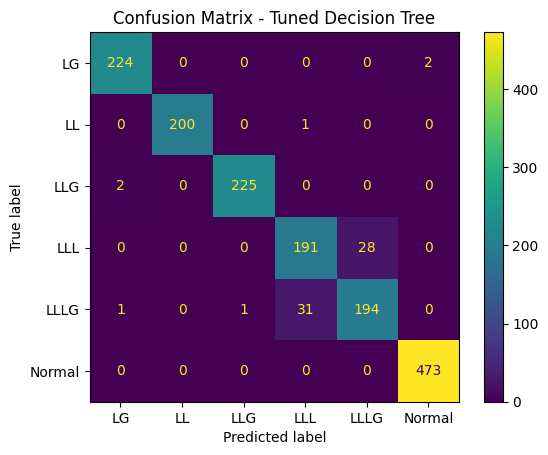

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_best = confusion_matrix(
    y_test_new,
    y_pred_best
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=best_dt.classes_
)

disp.plot()
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.show()

Feature Importance

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    best_dt.feature_importances_,
    index=X_new.columns
).sort_values(ascending=False)

print(importance)

I_mag          0.358407
V_mag          0.195134
Ic             0.177145
Va             0.116043
Ib             0.037047
Ia             0.034882
I_imbalance    0.029981
Vc             0.022379
V_imbalance    0.020780
Vb             0.008201
dtype: float64


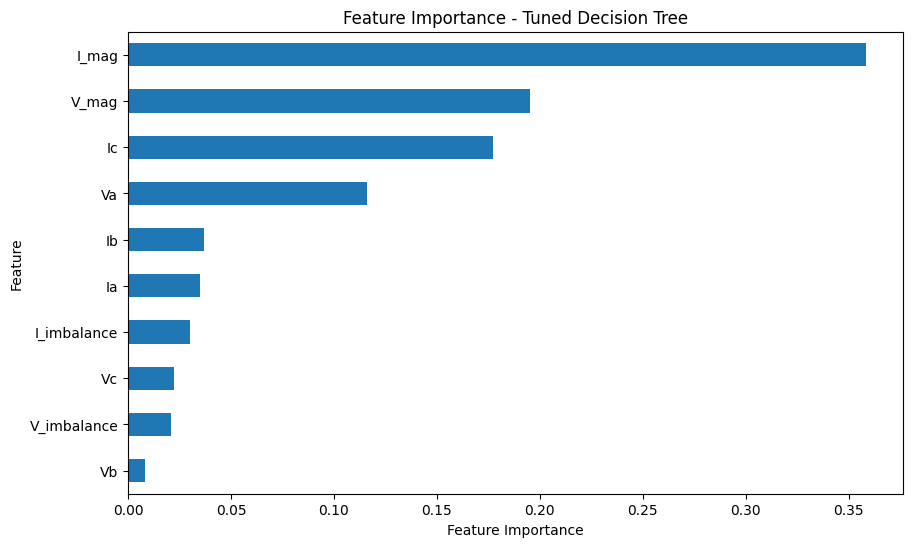

In [47]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind='barh')

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Tuned Decision Tree")

plt.show()

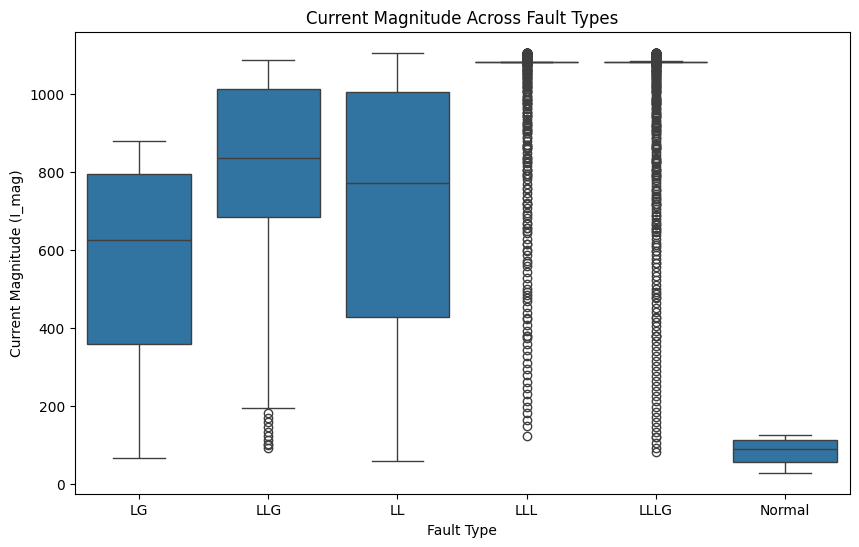

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    x=y,
    y=X_new["I_mag"]
)

plt.xlabel("Fault Type")
plt.ylabel("Current Magnitude (I_mag)")
plt.title("Current Magnitude Across Fault Types")
plt.show()

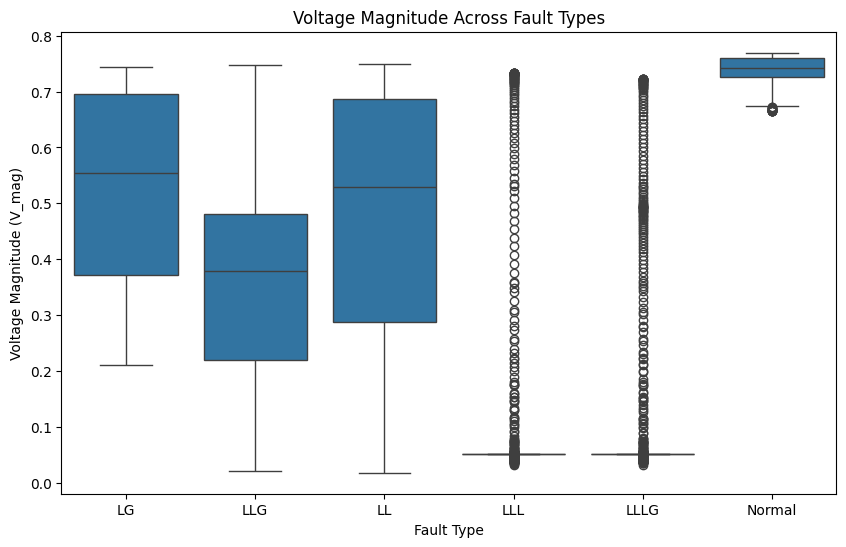

In [49]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=y,
    y=X_new["V_mag"]
)

plt.xlabel("Fault Type")
plt.ylabel("Voltage Magnitude (V_mag)")
plt.title("Voltage Magnitude Across Fault Types")
plt.show()

In [50]:
import numpy as np
import pandas as pd

def engineer_features(df):
    df = df.copy()

    df["I_mag"] = np.sqrt(
        df["Ia"]**2 + df["Ib"]**2 + df["Ic"]**2
    )

    df["V_mag"] = np.sqrt(
        df["Va"]**2 + df["Vb"]**2 + df["Vc"]**2
    )

    df["I_imbalance"] = (
        df[["Ia", "Ib", "Ic"]].max(axis=1)
        - df[["Ia", "Ib", "Ic"]].min(axis=1)
    )

    df["V_imbalance"] = (
        df[["Va", "Vb", "Vc"]].max(axis=1)
        - df[["Va", "Vb", "Vc"]].min(axis=1)
    )

    return df

In [51]:
X_check = engineer_features(
    data[["Ia", "Ib", "Ic", "Va", "Vb", "Vc"]]
)

print(X_check.head())
print(X_check.shape)

           Ia          Ib          Ic        Va        Vb        Vc  \
0 -151.291812   -9.677452   85.800162  0.400750 -0.132935 -0.267815   
1 -336.186183  -76.283262   18.328897  0.312732 -0.123633 -0.189099   
2 -502.891583 -174.648023  -80.924663  0.265728 -0.114301 -0.151428   
3 -593.941905 -217.703359 -124.891924  0.235511 -0.104940 -0.130570   
4 -643.663617 -224.159427 -132.282815  0.209537 -0.095554 -0.113983   

        I_mag     V_mag  I_imbalance  V_imbalance  
0  174.196824  0.499997   237.091975     0.668565  
1  345.219110  0.385804   354.515079     0.501831  
2  538.470684  0.326507   421.966920     0.417156  
3  644.794333  0.289009   469.049981     0.366081  
4  694.297519  0.256960   511.380802     0.323520  
(7861, 10)


In [52]:
from sklearn.tree import DecisionTreeClassifier

# Create the final tuned model
final_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train on all available data
final_model.fit(X_check, y)

print("Final model trained successfully!")

Final model trained successfully!


Save Final Model

In [53]:
import joblib

joblib.dump(final_model, "transmission_fault_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [54]:
feature_names = X_check.columns.tolist()

print(feature_names)

joblib.dump(feature_names, "feature_names.pkl")

print("Feature names saved successfully!")

['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc', 'I_mag', 'V_mag', 'I_imbalance', 'V_imbalance']
Feature names saved successfully!


In [55]:
import os

print(os.listdir())

['.config', 'classData.csv', 'transmission_fault_model.pkl', 'feature_names.pkl', 'sample_data']
